## Distribution Analysis  & Set Selection

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
CWD = Path().resolve()
DATA_PATH = CWD.parent / "Datasets"
SPICE = DATA_PATH / "spice-dataset"
RAMAN_1 = DATA_PATH / "Raman-ChEMBL-part1.db"
RAMAN_2 = DATA_PATH / "Raman-ChEMBL-part2.db"
QM7 = DATA_PATH / "datasets--qm7x/"

In [3]:
from dataset_readers import load_spice_hdf5, load_spice_dir_atom_counts, load_raman_db, load_raman_smiles_atoms, load_qm7x_atom_counts, load_qm7x

SPICE_HDF5 = DATA_PATH / "SPICE-2.0.1.hdf5"


In [4]:
# NOTE: These datasets are large. Set limits to integers to avoid memory issues.
SPICE_KEYS = ["smiles", "atomic_numbers"]
SPICE_FROM_DIR = True
SPICE_DIR_CACHE = SPICE / "_cache"
SPICE_WORKERS = 4
SPICE_MAX_FILES = None
SPICE_MAX_MOLS = None
SPICE_MAX_GROUPS = None
SPICE_MAX_CONFS = None
SPICE_CHUNKSIZE = None

RAMAN_DECODE_BLOB = True
RAMAN_FAST_ATOMS = True
RAMAN_WORKERS = 10
RAMAN_EXPAND_BLOB = True
RAMAN_COLUMNS = ["SMILES", "blob_data"]
RAMAN_LIMIT = None
RAMAN_CHUNKSIZE = None

QM7X_KEYS = ["atNUM"]
QM7X_FAST_ATOMS = True
QM7X_CACHE_DIR = QM7 / "_cache"
QM7X_WORKERS = 10
QM7X_MAX_FILES = None
QM7X_MAX_MOLS = None
QM7X_MAX_CONFS = None
QM7X_CHUNKSIZE = None


In [5]:
if RAMAN_FAST_ATOMS:
    raman1_df = load_raman_smiles_atoms(
        RAMAN_1,
        limit=RAMAN_LIMIT,
        chunksize=RAMAN_CHUNKSIZE or 2000,
        workers=RAMAN_WORKERS,
    )
    raman2_df = load_raman_smiles_atoms(
        RAMAN_2,
        limit=RAMAN_LIMIT,
        chunksize=RAMAN_CHUNKSIZE or 2000,
        workers=RAMAN_WORKERS,
    )
else:
    raman1_df = load_raman_db(
        RAMAN_1,
        decode_blob=RAMAN_DECODE_BLOB,
        expand_blob=RAMAN_EXPAND_BLOB,
        limit=RAMAN_LIMIT,
        columns=RAMAN_COLUMNS,
        chunksize=RAMAN_CHUNKSIZE,
    )
    raman2_df = load_raman_db(
        RAMAN_2,
        decode_blob=RAMAN_DECODE_BLOB,
        expand_blob=RAMAN_EXPAND_BLOB,
        limit=RAMAN_LIMIT,
        columns=RAMAN_COLUMNS,
        chunksize=RAMAN_CHUNKSIZE,
    )

    if "SMILES" in raman1_df.columns:
        raman1_df = raman1_df.rename(columns={"SMILES": "smiles"})
    if "SMILES" in raman2_df.columns:
        raman2_df = raman2_df.rename(columns={"SMILES": "smiles"})


In [6]:
if SPICE_FROM_DIR:
    spice_df = load_spice_dir_atom_counts(
        SPICE,
        max_files=SPICE_MAX_FILES,
        max_mols=SPICE_MAX_MOLS,
        chunksize=SPICE_CHUNKSIZE,
        cache_dir=SPICE_DIR_CACHE,
        workers=SPICE_WORKERS,
    )
else:
    spice_df = load_spice_hdf5(
        SPICE_HDF5,
        keys=SPICE_KEYS,
        max_groups=SPICE_MAX_GROUPS,
        max_confs=SPICE_MAX_CONFS,
        chunksize=SPICE_CHUNKSIZE,
    )


In [7]:
if QM7X_FAST_ATOMS:
    qm7x_df = load_qm7x_atom_counts(
        QM7,
        max_files=QM7X_MAX_FILES,
        max_mols=QM7X_MAX_MOLS,
        max_confs=QM7X_MAX_CONFS,
        chunksize=QM7X_CHUNKSIZE,
        cache_dir=QM7X_CACHE_DIR,
        workers=QM7X_WORKERS,
    )
else:
    qm7x_df = load_qm7x(
        QM7,
        keys=QM7X_KEYS,
        max_files=QM7X_MAX_FILES,
        max_mols=QM7X_MAX_MOLS,
        max_confs=QM7X_MAX_CONFS,
        chunksize=QM7X_CHUNKSIZE,
        cache_dir=QM7X_CACHE_DIR,
    )


### Viewing the Dataframes

In [8]:
raman1_df.head()

,id,smiles,num_atoms
0,1,N#Cc1ccc2c(c1)[C@@H](N1CCCC1=O)[C@@H](C(O2)(C)C)O,39
1,2,CCC[C@@H]1C(=C(C)N=C(/C/1=C(/OC)\O)C)C(=O)OCC,43
2,3,CCO/C(=C\1/C(=NC(=C([C@H]1C)C(=O)OCCSc1ccccc1)...,51
3,4,NCCCC[C@H](C(=O)N[C@H](C(=O)CCC(=O)N1CCC[C@H]1...,78
4,5,NCCCNCCCCN(C(=O)CC(=O)NCCCCCC[N]C(=[NH2])N)C,66


In [9]:
raman2_df.head()

,id,smiles,num_atoms
0,1,C[C@@H]1CCCC[C@]1(N)c1ccccc1,33
1,2,O=C(c1cccc(=O)[nH]1)OCc1ccc2c(c1)OCO2,31
2,3,NCCNC1=[N]=C(N=C([N]1)N[C@]12C[C@H]3C[C@@H](C2...,66
3,4,COc1ccccc1C1=Nn2c(SC1)nnc2c1ccccc1C,40
4,5,Brc1cccc(c1)[S]([O])[O].NC(=N)NC(=O)Cn1c(ccc1c...,57


In [10]:
spice_df.head()

,mol_id,smiles,num_atoms,subset,source_file
0,00S ALA,[N:3](=[C:6]([c:11]1[c:7]([H:23])[c:9]([H:25])...,44,amino-acid-ligand,amino-acid-ligand-21-25.hdf5.gz
1,00S ASN,[N:4](=[C:8]([c:13]1[c:9]([H:26])[c:11]([H:28]...,48,amino-acid-ligand,amino-acid-ligand-21-25.hdf5.gz
2,00S ASP,[N:5](=[C:9]([c:14]1[c:10]([H:26])[c:12]([H:28...,46,amino-acid-ligand,amino-acid-ligand-21-25.hdf5.gz
3,00S GLY,[N:3](=[C:6]([c:11]1[c:7]([H:22])[c:9]([H:24])...,41,amino-acid-ligand,amino-acid-ligand-21-25.hdf5.gz
4,00S HIS,[N:3](=[C:6]([c:14]1[c:10]([H:30])[c:12]([H:32...,52,amino-acid-ligand,amino-acid-ligand-21-25.hdf5.gz


In [11]:
qm7x_df.head()

,mol_id,conf_id,num_atoms,source_file
0,1,Geom-m1-i1-c1-d1,5,1000.xz
1,1,Geom-m1-i1-c1-d10,5,1000.xz
2,1,Geom-m1-i1-c1-d100,5,1000.xz
3,1,Geom-m1-i1-c1-d11,5,1000.xz
4,1,Geom-m1-i1-c1-d12,5,1000.xz


### Distribution Analysis

In [12]:
def _count_atoms(value):
    if value is None:
        return None
    try:
        return len(value)
    except TypeError:
        return None

def add_num_atoms(df, source):
    df = df.copy()
    if "num_atoms" in df.columns:
        return df
    if source == "spice":
        df["num_atoms"] = df["atomic_numbers"].apply(_count_atoms)
    elif source == "raman":
        df["num_atoms"] = df["atoms"].apply(_count_atoms)
    elif source == "qm7x":
        df["num_atoms"] = df["atNUM"].apply(_count_atoms)
    else:
        raise ValueError(f"Unknown source: {source}")
    return df

def add_atom_buckets(df, bin_size=5, col="num_atoms", bucket_col="atom_bucket"):
    df = df.copy()
    if bucket_col in df.columns:
        return df
    max_val = int(df[col].dropna().max()) if df[col].notna().any() else 0
    bins = list(range(0, max_val + bin_size + 1, bin_size))
    if len(bins) < 2:
        bins = [0, bin_size]
    df[bucket_col] = pd.cut(df[col], bins=bins, right=False)
    return df

def plot_atom_buckets(df, bucket_col="atom_bucket", title=None):
    counts = df[bucket_col].value_counts().sort_index()
    ax = counts.plot(kind="bar", figsize=(12, 4))
    ax.set_xlabel("Atom count buckets")
    ax.set_ylabel("Molecules")
    if title:
        ax.set_title(title)
    return ax


In [13]:
ATOM_BIN_SIZE = 5

spice_df = add_num_atoms(spice_df, "spice")
raman1_df = add_num_atoms(raman1_df, "raman")
raman2_df = add_num_atoms(raman2_df, "raman")
qm7x_df = add_num_atoms(qm7x_df, "qm7x")

spice_df = add_atom_buckets(spice_df, bin_size=ATOM_BIN_SIZE)
raman1_df = add_atom_buckets(raman1_df, bin_size=ATOM_BIN_SIZE)
raman2_df = add_atom_buckets(raman2_df, bin_size=ATOM_BIN_SIZE)
qm7x_df = add_atom_buckets(qm7x_df, bin_size=ATOM_BIN_SIZE)


<Axes: title={'center': 'SPICE: atom count distribution'}, xlabel='Atom count buckets', ylabel='Molecules'>

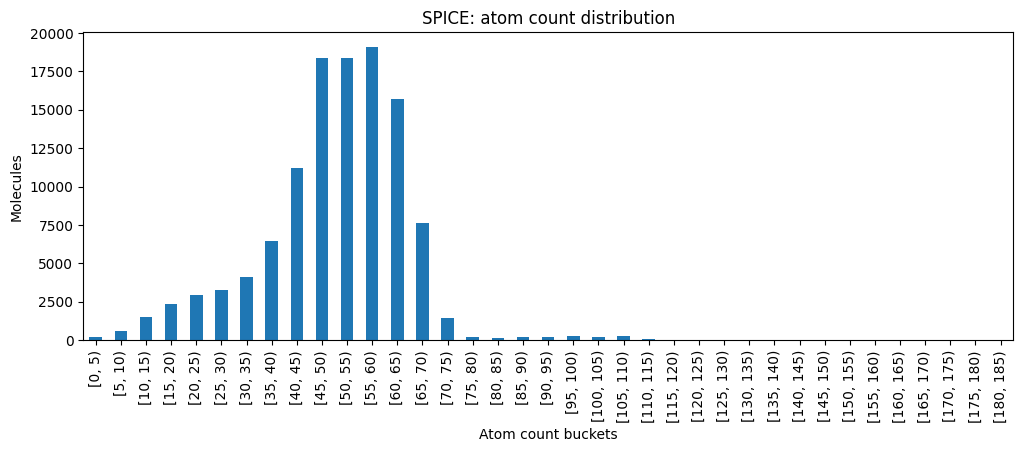

In [14]:
plot_atom_buckets(spice_df, title="SPICE: atom count distribution")

<Axes: title={'center': 'Raman part1: atom count distribution'}, xlabel='Atom count buckets', ylabel='Molecules'>

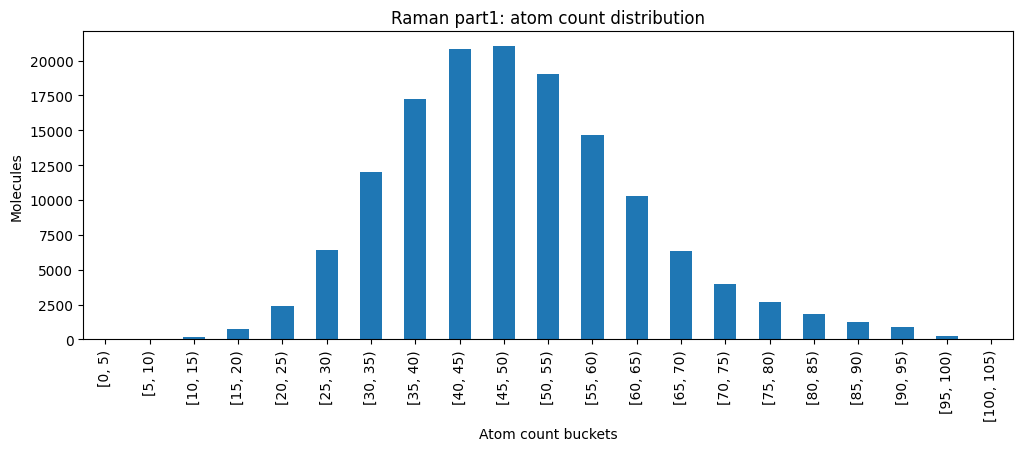

In [15]:
plot_atom_buckets(raman1_df, title="Raman part1: atom count distribution")

<Axes: title={'center': 'Raman part2: atom count distribution'}, xlabel='Atom count buckets', ylabel='Molecules'>

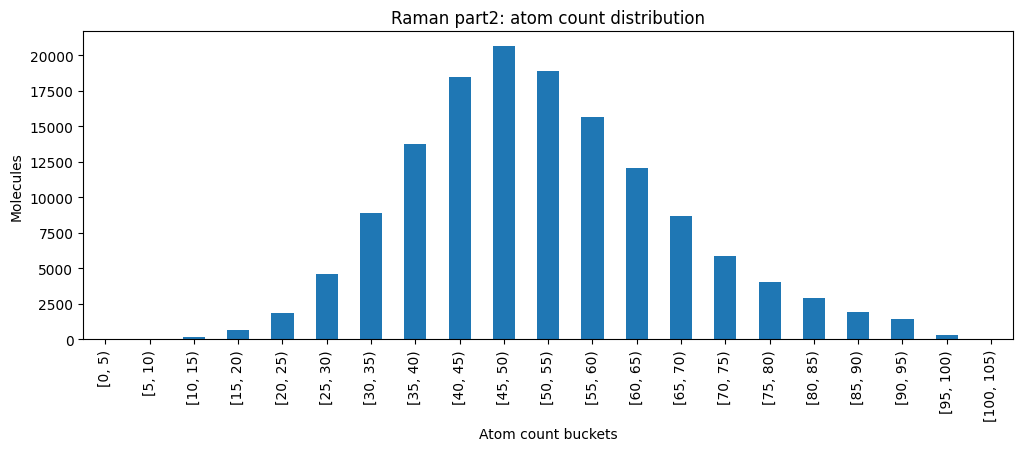

In [16]:
plot_atom_buckets(raman2_df, title="Raman part2: atom count distribution")

<Axes: title={'center': 'QM7-X: atom count distribution'}, xlabel='Atom count buckets', ylabel='Molecules'>

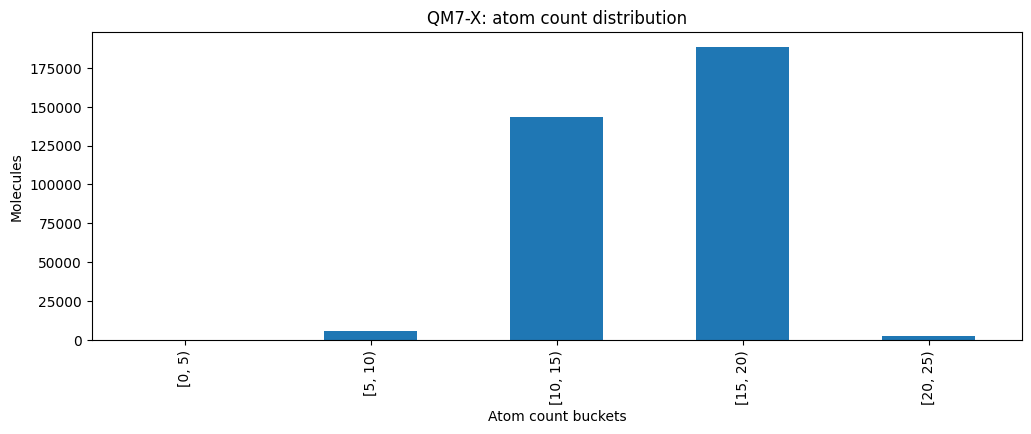

In [17]:
plot_atom_buckets(qm7x_df, title="QM7-X: atom count distribution")

In [18]:
def stratified_sample(df, bucket_col, n, random_state=0):
    if n <= 0:
        return df.iloc[0:0].copy()
    counts = df[bucket_col].value_counts()
    if counts.sum() == 0:
        return df.iloc[0:0].copy()
    proportions = counts / counts.sum()
    target = (proportions * n)
    base = target.astype(int)
    remainder = n - base.sum()
    if remainder > 0:
        frac = (target - base).sort_values(ascending=False)
        for bucket in frac.index[:remainder]:
            base[bucket] += 1
    samples = []
    for bucket, k in base.items():
        if k <= 0:
            continue
        group = df[df[bucket_col] == bucket]
        k = min(k, len(group))
        if k > 0:
            samples.append(group.sample(n=k, random_state=random_state))
    if not samples:
        return df.iloc[0:0].copy()
    return pd.concat(samples, ignore_index=True)

# Example usage (adjust N as needed)
SPICE_SAMPLE_N = 10000
RAMAN_SAMPLE_N = 50000
QM7X_SAMPLE_N = 50000

spice_sample = stratified_sample(spice_df, "atom_bucket", SPICE_SAMPLE_N, random_state=42)
raman1_sample = stratified_sample(raman1_df, "atom_bucket", RAMAN_SAMPLE_N, random_state=42)
raman2_sample = stratified_sample(raman2_df, "atom_bucket", RAMAN_SAMPLE_N, random_state=42)
qm7x_sample = stratified_sample(qm7x_df, "atom_bucket", QM7X_SAMPLE_N, random_state=42)


{'spice_max_abs_diff': np.float64(5.4893932133989656e-05),
 'raman1_max_abs_diff': np.float64(1.0181367579137216e-05),
 'raman2_max_abs_diff': np.float64(9.990410910251657e-06),
 'qm7x_max_abs_diff': np.float64(8.171021377734178e-06)}

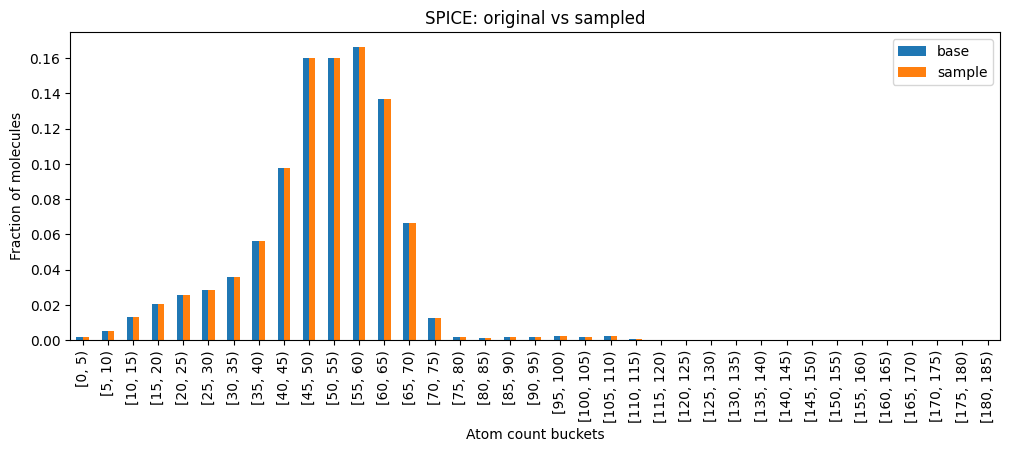

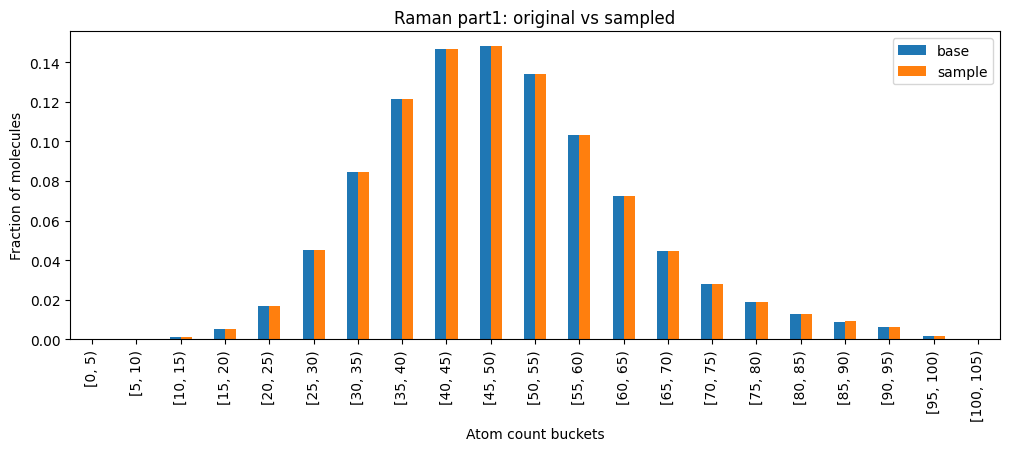

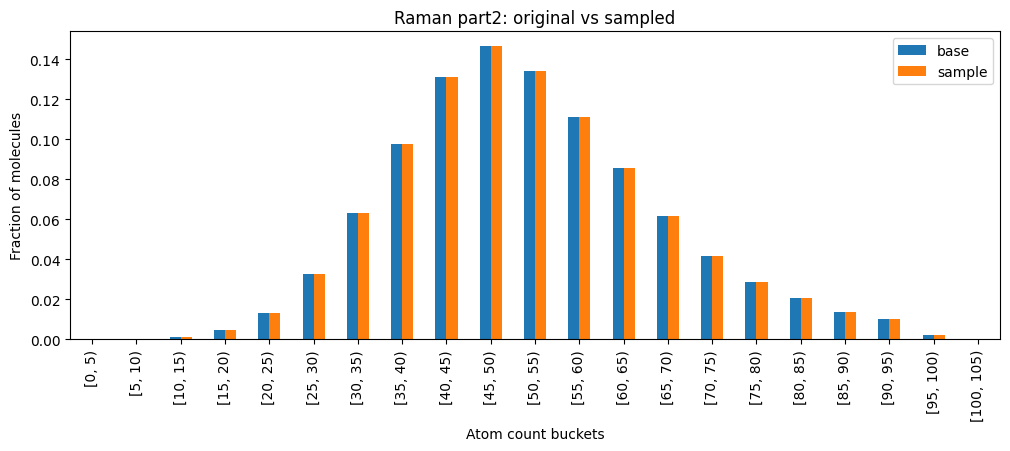

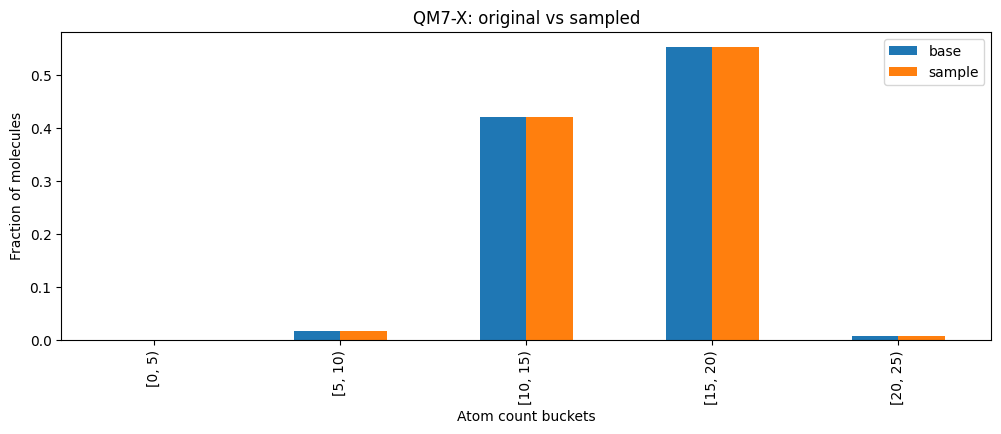

In [19]:
def compare_distribution(df, sample_df, bucket_col="atom_bucket"):
    base = df[bucket_col].value_counts().sort_index()
    sample = sample_df[bucket_col].value_counts().sort_index()
    idx = base.index.union(sample.index)
    base = (base / base.sum()).reindex(idx, fill_value=0)
    sample = (sample / sample.sum()).reindex(idx, fill_value=0)
    out = pd.DataFrame({"base": base, "sample": sample})
    out["abs_diff"] = (out["sample"] - out["base"]).abs()
    return out

def plot_distribution_compare(df, sample_df, title, bucket_col="atom_bucket"):
    comp = compare_distribution(df, sample_df, bucket_col=bucket_col)
    ax = comp[["base", "sample"]].plot(kind="bar", figsize=(12, 4))
    ax.set_xlabel("Atom count buckets")
    ax.set_ylabel("Fraction of molecules")
    ax.set_title(title)
    return comp

spice_comp = plot_distribution_compare(spice_df, spice_sample, "SPICE: original vs sampled")
raman1_comp = plot_distribution_compare(raman1_df, raman1_sample, "Raman part1: original vs sampled")
raman2_comp = plot_distribution_compare(raman2_df, raman2_sample, "Raman part2: original vs sampled")
qm7x_comp = plot_distribution_compare(qm7x_df, qm7x_sample, "QM7-X: original vs sampled")

# Quick numeric check (max abs diff per dataset)
{
    "spice_max_abs_diff": spice_comp["abs_diff"].max(),
    "raman1_max_abs_diff": raman1_comp["abs_diff"].max(),
    "raman2_max_abs_diff": raman2_comp["abs_diff"].max(),
    "qm7x_max_abs_diff": qm7x_comp["abs_diff"].max(),
}


In [20]:
LARGE_ATOM_THRESHOLD = 100

spice_max_atoms = spice_df["num_atoms"].max()
spice_large = spice_df[spice_df["num_atoms"] >= LARGE_ATOM_THRESHOLD]
spice_top = spice_df.sort_values("num_atoms", ascending=False).head(20)

(spice_max_atoms, len(spice_large))

spice_top[["smiles", "num_atoms", "subset", "source_file"]]


,smiles,num_atoms,subset,source_file
114784,[O:10]([H:79])[H:80].[O:11]([H:81])[H:82].[O:1...,180,water,water60.hdf5
114690,[O:1]=[C:9]([N:30]([C:44]([C:11](=[O:3])[N:31]...,110,test,test-dataset.hdf5
113736,[O:1]=[C:5]([c:11]1[c:9]([H:28])[c:10]([H:29])...,110,solvated-pubchem,solvated-pubchem-1-1500.hdf5
113735,[O:1]=[C:8]([C:23]1=[C:12]([H:35])[O:5][C:11](...,110,solvated-pubchem,solvated-pubchem-1-1500.hdf5
113733,[Cl:1][C:10]1=[C:11]([N:19]2[C:21]([H:37])([H:...,110,solvated-pubchem,solvated-pubchem-1-1500.hdf5
113731,[O:1]=[C:9]1[S:8][c:20]2[c:16]([H:38])[c:22]([...,110,solvated-pubchem,solvated-pubchem-1-1500.hdf5
113727,[O:1]=[C:5]([N:15]([C:20]([C:24]1([H:48])[N:4]...,110,solvated-pubchem,solvated-pubchem-1-1500.hdf5
113724,[O:1]=[S:29]1(=[O:2])[C:9]([N:22]([C:25]([C:27...,110,solvated-pubchem,solvated-pubchem-1-1500.hdf5
112607,[N:1]#[C:3][C:16]([C:4]#[N:2])([C:8]1=[N:5][C:...,110,solvated-pubchem,solvated-pubchem-1-1500.hdf5
113718,[O:1]=[C:5]1[c:15]2[c:13]([H:33])[c:11]([H:31]...,110,solvated-pubchem,solvated-pubchem-1-1500.hdf5


In [21]:
spice_molecules = spice_df["smiles"].dropna().unique().tolist()
raman1_molecules = raman1_df["smiles"].dropna().unique().tolist()
raman2_molecules = raman2_df["smiles"].dropna().unique().tolist()
qm7x_molecules = qm7x_df["mol_id"].dropna().unique().tolist()

(len(spice_molecules), len(raman1_molecules), len(raman2_molecules), len(qm7x_molecules))


(112797, 141923, 140633, 935)

In [28]:
pd.Series(spice_molecules).head()
pd.Series(spice_molecules).to_csv('./spice_mols.csv')

In [29]:
pd.Series(raman1_molecules).head()
pd.Series(raman1_molecules).to_csv('./raman1_mols.csv')

In [30]:
pd.Series(raman2_molecules).head()
pd.Series(raman2_molecules).to_csv('./raman2_mols.csv')

In [25]:
pd.Series(qm7x_molecules).head()

0       1
1      10
2     100
3    1000
4     101
dtype: object

In [48]:
qm7x_df

,mol_id,conf_id,num_atoms,source_file,atom_bucket
0,1,Geom-m1-i1-c1-d1,5,1000.xz,"[5, 10)"
1,1,Geom-m1-i1-c1-d10,5,1000.xz,"[5, 10)"
2,1,Geom-m1-i1-c1-d100,5,1000.xz,"[5, 10)"
3,1,Geom-m1-i1-c1-d11,5,1000.xz,"[5, 10)"
4,1,Geom-m1-i1-c1-d12,5,1000.xz,"[5, 10)"
...,...,...,...,...,...
340163,999,Geom-m999-i1-c1-d96,15,1000.xz,"[15, 20)"
340164,999,Geom-m999-i1-c1-d97,15,1000.xz,"[15, 20)"
340165,999,Geom-m999-i1-c1-d98,15,1000.xz,"[15, 20)"
340166,999,Geom-m999-i1-c1-d99,15,1000.xz,"[15, 20)"


In [41]:
spice_sample = stratified_sample(spice_df, "atom_bucket", 96, random_state=42)
raman1_sample = stratified_sample(raman1_df, "atom_bucket", 96, random_state=42)
raman1_sample = stratified_sample(raman2_df, "atom_bucket", 96, random_state=42)

In [42]:
spice_molecules = spice_sample["smiles"].dropna().unique().tolist()
raman1_molecules = raman1_sample["smiles"].dropna().unique().tolist()
raman2_molecules = raman2_sample["smiles"].dropna().unique().tolist()

In [43]:
len(spice_molecules)

96

In [44]:
len(raman1_molecules)

96

In [45]:
len(raman2_molecules)

24

In [46]:
pd.Series(spice_molecules).to_csv('./spice_mols_96.csv')
pd.Series(raman1_molecules).to_csv('./raman1_mols_96.csv')
pd.Series(raman2_molecules).to_csv('./raman2_mols_96.csv')